In [1]:
import pandas as pd

## Resources

This analysis utilizes the following Python libraries:
*   **pandas**: For data manipulation and analysis.
*   **scikit-learn**: For machine learning tasks such as data splitting, model training (Random Forest Classifier), and evaluation metrics (accuracy score, confusion matrix).
*   **matplotlib**: For creating static, interactive, and animated visualizations.
*   **seaborn**: For making attractive and informative statistical graphics.

In [2]:
df_crop_recommendation = pd.read_csv('/content/Crop_recommendation.csv')
display(df_crop_recommendation.head())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
display(df_crop_recommendation.describe())

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [4]:
print('Missing values in df_crop_recommendation:')
display(df_crop_recommendation.isnull().sum())

Missing values in df_crop_recommendation:


,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


### Separate Features and Target Variable

We will define the features (`X`) as all columns except 'label', and the target variable (`y`) as the 'label' column itself. The 'label' column represents the crop to be recommended, which is a categorical variable.

In [5]:
X = df_crop_recommendation.drop('label', axis=1)
y = df_crop_recommendation['label']

print('Features (X) shape:', X.shape)
print('Target (y) shape:', y.shape)

Features (X) shape: (2200, 7)
Target (y) shape: (2200,)


### Encode the Target Variable

The target variable 'label' is currently in a categorical (text) format. To use it in most machine learning models, we need to convert it into numerical format. We'll use `LabelEncoder` from `sklearn.preprocessing` for this purpose.

In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Original labels:', y.unique()[:5]) # Display first 5 unique original labels
print('Encoded labels:', y_encoded[:5]) # Display first 5 encoded labels
print('Mapping of labels to encoded values:')
for i, label in enumerate(le.classes_):
    print(f'{label}: {i}')

Original labels: ['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas']
Encoded labels: [20 20 20 20 20]
Mapping of labels to encoded values:
apple: 0
banana: 1
blackgram: 2
chickpea: 3
coconut: 4
coffee: 5
cotton: 6
grapes: 7
jute: 8
kidneybeans: 9
lentil: 10
maize: 11
mango: 12
mothbeans: 13
mungbean: 14
muskmelon: 15
orange: 16
papaya: 17
pigeonpeas: 18
pomegranate: 19
rice: 20
watermelon: 21


### Split Data into Training and Testing Sets

To evaluate the performance of our machine learning model, we need to split the data into two sets: a training set and a testing set. The model will learn from the training set, and its performance will be assessed on the testing set, which it has not seen before. We'll use a standard split of 80% for training and 20% for testing.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (1760, 7)
X_test shape: (440, 7)
y_train shape: (1760,)
y_test shape: (440,)


### Train a Random Forest Classifier

Now that our data is split, we can proceed to train a machine learning model. We'll use a Random Forest Classifier, which is an ensemble learning method suitable for classification tasks. It builds multiple decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
rf_classifier.fit(X_train, y_train)

print('Random Forest Classifier trained successfully!')

Random Forest Classifier trained successfully!


### Evaluate Model Performance

After training the model, it's crucial to evaluate its performance on the test set. This helps us understand how well the model generalizes to new, unseen data. We will use accuracy as our primary metric for this classification task.

In [34]:
df_final_agriculture = pd.read_csv('/content/final_agriculture_dataset.csv')
print('First 5 rows of final_agriculture_dataset:')
display(df_final_agriculture.head())

First 5 rows of final_agriculture_dataset:


,N,P,K,temperature,humidity,ph,rainfall,crop_type,soil_moisture,growth_stage,crop_health,water_required,fertilizer_level
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,34,Seedling,Poor,Low,Low
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,71,Seedling,Good,Low,Low
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,57,Seedling,Moderate,Low,Medium
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,77,Vegetative,Moderate,Low,High
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,45,Flowering,Poor,Low,Low


### Summary Statistics for `df_final_agriculture`

Let's examine the summary statistics for the `df_final_agriculture` dataset to understand the distribution and characteristics of its numerical features. We will also look at the unique values and counts for categorical features.

In [35]:
print('Summary statistics for numerical columns:')
display(df_final_agriculture.describe())

print('\nSummary statistics for categorical columns:')
display(df_final_agriculture.describe(include='object'))

Summary statistics for numerical columns:


,N,P,K,temperature,humidity,ph,rainfall,soil_moisture
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655,49.215000
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389,17.243004
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267,20.000000
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686,34.000000
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624,49.000000
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508,64.000000
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117,79.000000



Summary statistics for categorical columns:


,crop_type,growth_stage,crop_health,water_required,fertilizer_level
count,2200,2200,2200,2200,2200
unique,22,3,3,3,3
top,rice,Seedling,Poor,Medium,High
freq,100,750,768,1173,1886


In [37]:
print('Mean values of features grouped by Crop Type in df_final_agriculture:')
mean_by_crop_type = df_final_agriculture.groupby('crop_type').mean(numeric_only=True)
display(mean_by_crop_type)

Mean values of features grouped by Crop Type in df_final_agriculture:


,N,P,K,temperature,humidity,ph,rainfall,soil_moisture
crop_type,,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779,47.63
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980,46.55
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151,50.45
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977,47.59
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646,52.59
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295,52.48
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043,49.65
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829,47.78
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798,51.08


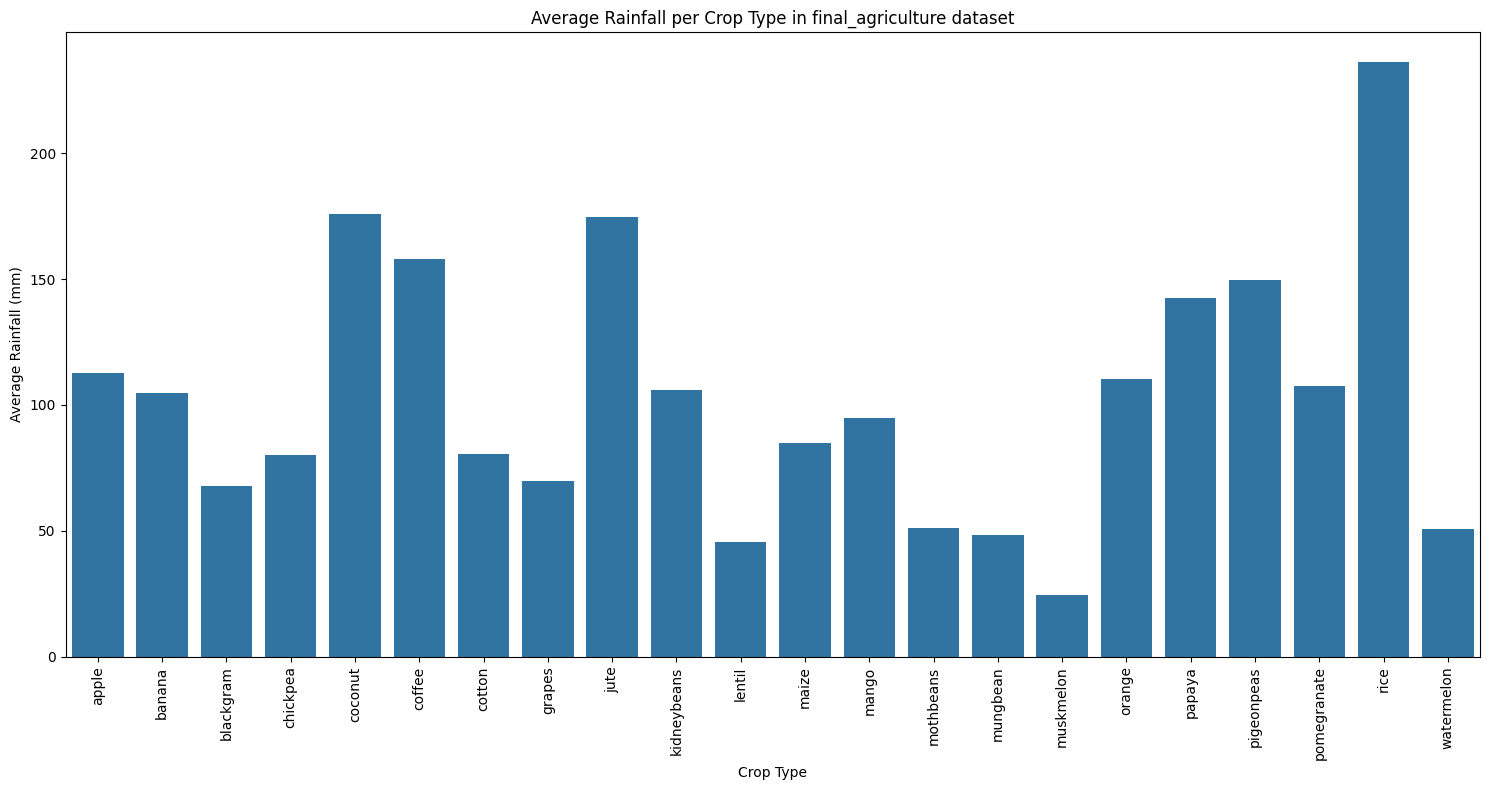

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.barplot(x=mean_by_crop_type.index, y='rainfall', data=mean_by_crop_type)
plt.title('Average Rainfall per Crop Type in final_agriculture dataset')
plt.xlabel('Crop Type')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Load and Display 'Fertilizer Prediction.csv'

In [24]:
df_fertilizer = pd.read_csv('/content/Fertilizer Prediction.csv')
display(df_fertilizer.head())

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


### Summary Statistics for `df_fertilizer`

Let's examine the summary statistics for the `df_fertilizer` dataset to understand the distribution and characteristics of its numerical features. We will also look at the unique values and counts for categorical features.

In [25]:
print('Summary statistics for numerical columns:')
display(df_fertilizer.describe())

print('\nSummary statistics for categorical columns:')
display(df_fertilizer.describe(include='object'))

Summary statistics for numerical columns:


,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,30.282828,59.151515,43.181818,18.909091,3.383838,18.606061
std,3.502304,5.840331,11.271568,11.599693,5.814667,13.476978
min,25.000000,50.000000,25.000000,4.000000,0.000000,0.000000
25%,28.000000,54.000000,34.000000,10.000000,0.000000,9.000000
50%,30.000000,60.000000,41.000000,13.000000,0.000000,19.000000
75%,33.000000,64.000000,50.500000,24.000000,7.500000,30.000000
max,38.000000,72.000000,65.000000,42.000000,19.000000,42.000000



Summary statistics for categorical columns:


,Soil Type,Crop Type,Fertilizer Name
count,99,99,99
unique,5,11,7
top,Loamy,Sugarcane,Urea
freq,21,13,22


### Distribution of Fertilizer Recommendations by Crop Type

Let's visualize the distribution of fertilizer recommendations for each crop type. This will help us understand which fertilizers are commonly suggested for particular crops based on the dataset.

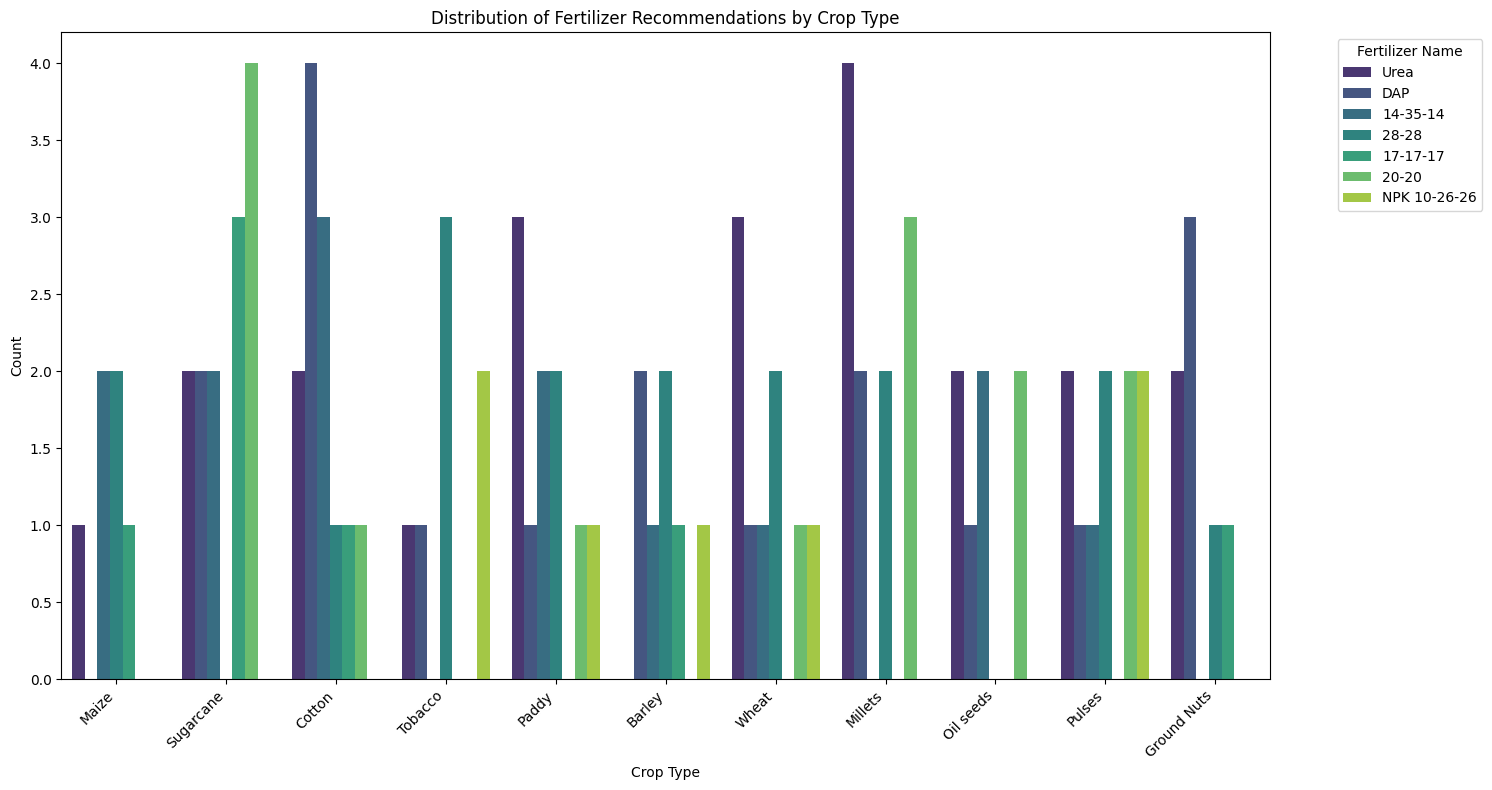

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.countplot(data=df_fertilizer, x='Crop Type', hue='Fertilizer Name', palette='viridis')
plt.title('Distribution of Fertilizer Recommendations by Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Fertilizer Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import accuracy_score

# Make predictions on the test set
y_pred = rf_classifier.predict(X_test)

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f'Model Accuracy on the test set: {accuracy:.2f}')

Model Accuracy on the test set: 0.99


### Confusion Matrix

To get a more detailed view of the model's performance, especially how well it distinguishes between different crop types, we'll generate a confusion matrix. This matrix will show us where the model made correct predictions (diagonal elements) and where it made incorrect ones (off-diagonal elements).

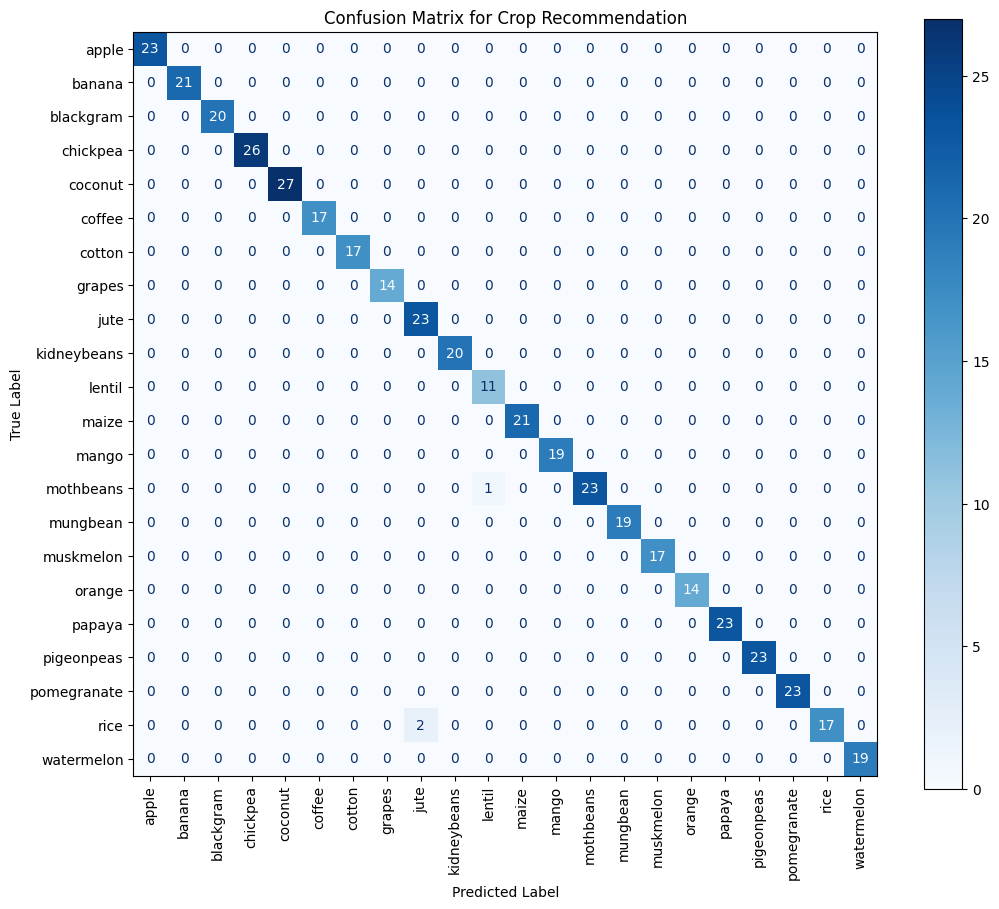

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels from the LabelEncoder
class_labels = le.classes_

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix for Crop Recommendation')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Feature Importance Analysis

Understanding feature importance can provide insights into which environmental factors are most influential in determining crop recommendations. The Random Forest Classifier can rank features based on their contribution to the model's predictive accuracy.

Feature Importances:


,Feature,Importance
6,rainfall,0.227036
4,humidity,0.211279
2,K,0.181222
1,P,0.143622
0,N,0.108859
3,temperature,0.075682
5,ph,0.052301


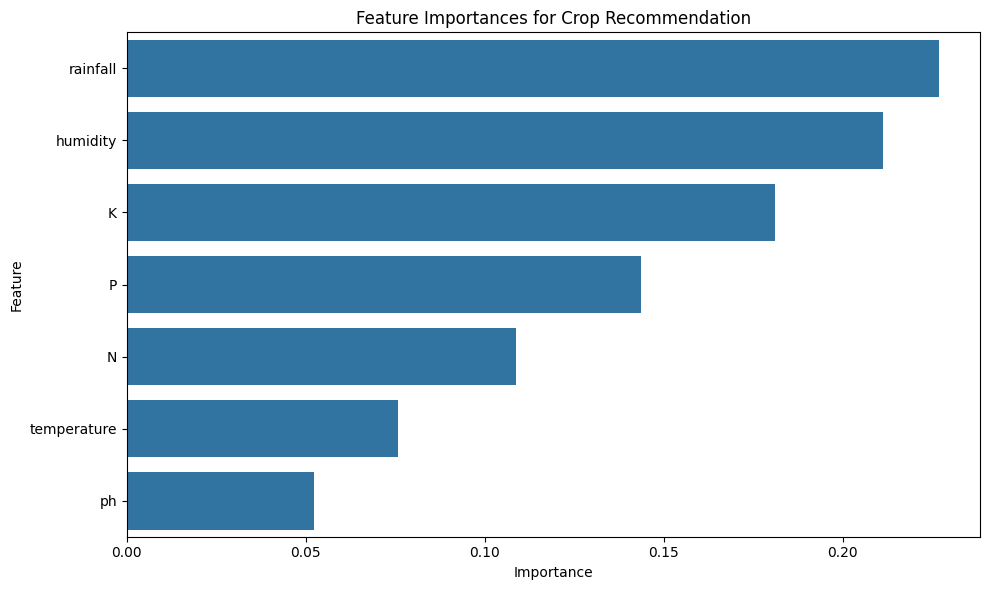

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest Classifier
feature_importances = rf_classifier.feature_importances_

# Get feature names from the training data (X_train)
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the DataFrame by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the feature importances
print('Feature Importances:')
display(importance_df)

# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importances for Crop Recommendation')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [28]:
display(importance_df)

,Feature,Importance
6,rainfall,0.227036
4,humidity,0.211279
2,K,0.181222
1,P,0.143622
0,N,0.108859
3,temperature,0.075682
5,ph,0.052301


### Predict Crop Label for New Soil Data

Let's use the trained Random Forest Classifier (`rf_classifier`) to predict the crop label for a hypothetical new set of soil and environmental conditions. We'll create a sample input and then use the model to make a prediction.

In [29]:
import pandas as pd

# Create a DataFrame for new soil data, ensuring column order matches X_train
# Example values (replace with actual new data if available)
new_soil_data = pd.DataFrame([
    {
        'N': 80,
        'P': 50,
        'K': 45,
        'temperature': 25.0,
        'humidity': 75.0,
        'ph': 6.5,
        'rainfall': 180.0
    }
])

print('New soil data for prediction:')
display(new_soil_data)

New soil data for prediction:


,N,P,K,temperature,humidity,ph,rainfall
0,80,50,45,25.0,75.0,6.5,180.0


In [30]:
# Predict the crop label using the trained model
predicted_label_encoded = rf_classifier.predict(new_soil_data)

# Decode the predicted label back to the original crop name
predicted_crop_label = le.inverse_transform(predicted_label_encoded)

print(f'Predicted crop label for the new soil data: {predicted_crop_label[0]}')

Predicted crop label for the new soil data: jute


### Suggest Fertilizer Based on Predicted Crop and Soil Data

Now, let's use the predicted crop label ('jute') and the original fertilizer prediction dataset (`df_fertilizer`) to suggest a suitable fertilizer. We'll filter the `df_fertilizer` to show recommendations specifically for 'jute'.

In [32]:
# Get the predicted crop label
predicted_crop = predicted_crop_label[0]

# Filter the fertilizer DataFrame for the predicted crop type
recommended_fertilizer_df = df_fertilizer[df_fertilizer['Crop Type'] == predicted_crop]

print(f'Fertilizer recommendations for the predicted crop: {predicted_crop}')
display(recommended_fertilizer_df[['Fertilizer Name', 'Nitrogen', 'Phosphorous', 'Potassium']].drop_duplicates())

Fertilizer recommendations for the predicted crop: jute


,Fertilizer Name,Nitrogen,Phosphorous,Potassium


In [33]:
print('Unique Crop Types in df_fertilizer:')
display(df_fertilizer['Crop Type'].unique())

Unique Crop Types in df_fertilizer:


array(['Maize', 'Sugarcane', 'Cotton', 'Tobacco', 'Paddy', 'Barley',
       'Wheat', 'Millets', 'Oil seeds', 'Pulses', 'Ground Nuts'],
      dtype=object)

### Relationship between Rainfall and Crop Labels

Now, let's explore how rainfall varies across different crop types. This analysis can reveal patterns indicating which crops are more suited to certain rainfall levels.

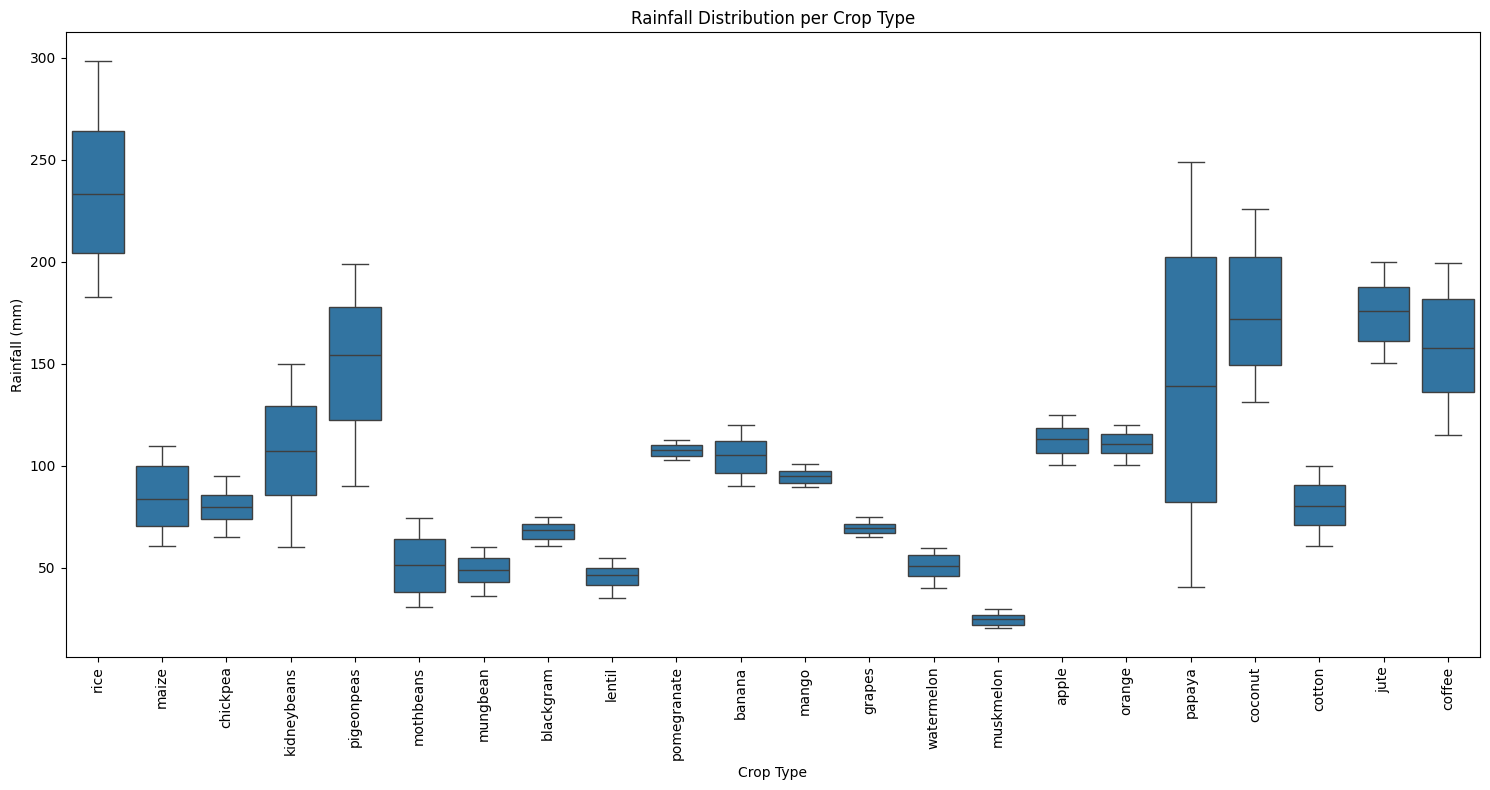

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='rainfall', data=df_crop_recommendation)
plt.title('Rainfall Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Relationship between Temperature and Crop Labels

Following the rainfall analysis, let's now examine how temperature varies for different crop types. This visualization will help identify optimal temperature ranges for each crop.

### Relationship between Temperature and Crop Labels

Following the rainfall analysis, let's now examine how temperature varies for different crop types. This visualization will help identify optimal temperature ranges for each crop.

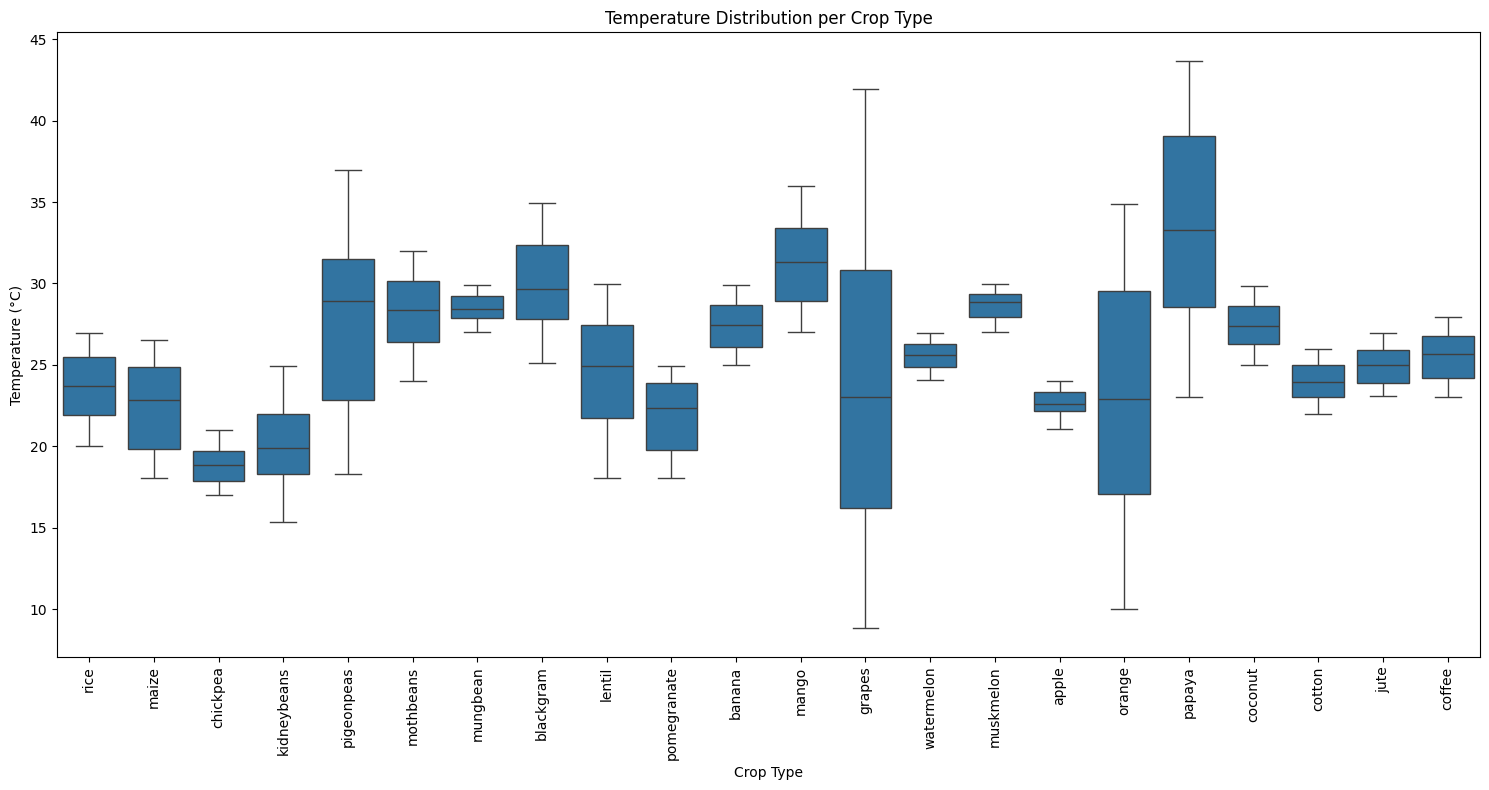

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='temperature', data=df_crop_recommendation)
plt.title('Temperature Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

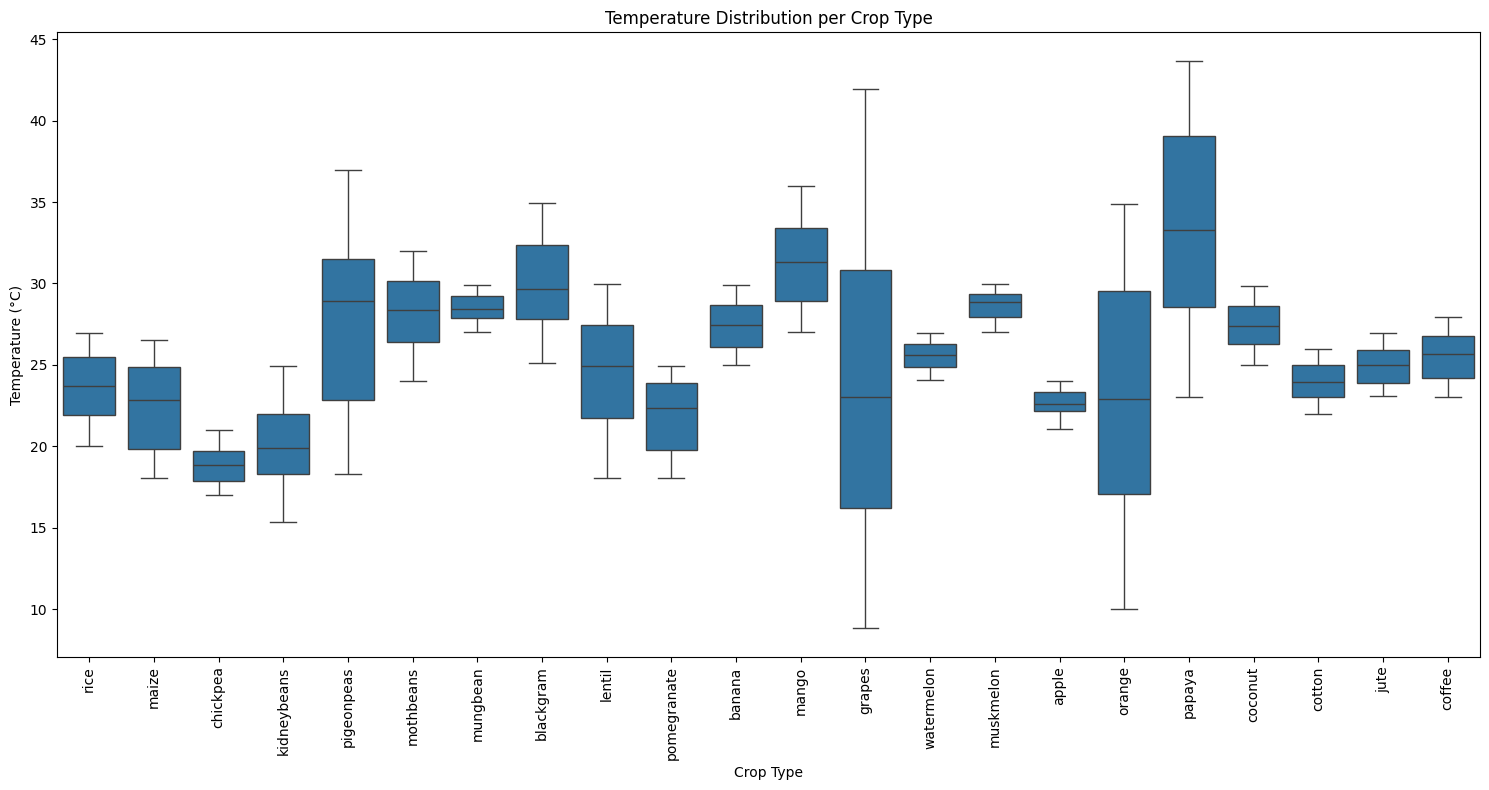

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='temperature', data=df_crop_recommendation)
plt.title('Temperature Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Temperature (°C)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Relationship between Humidity and Crop Labels

To complete our analysis of environmental factors, let's now visualize how humidity levels vary across different crop types. This will provide insights into the preferred humidity conditions for each crop.

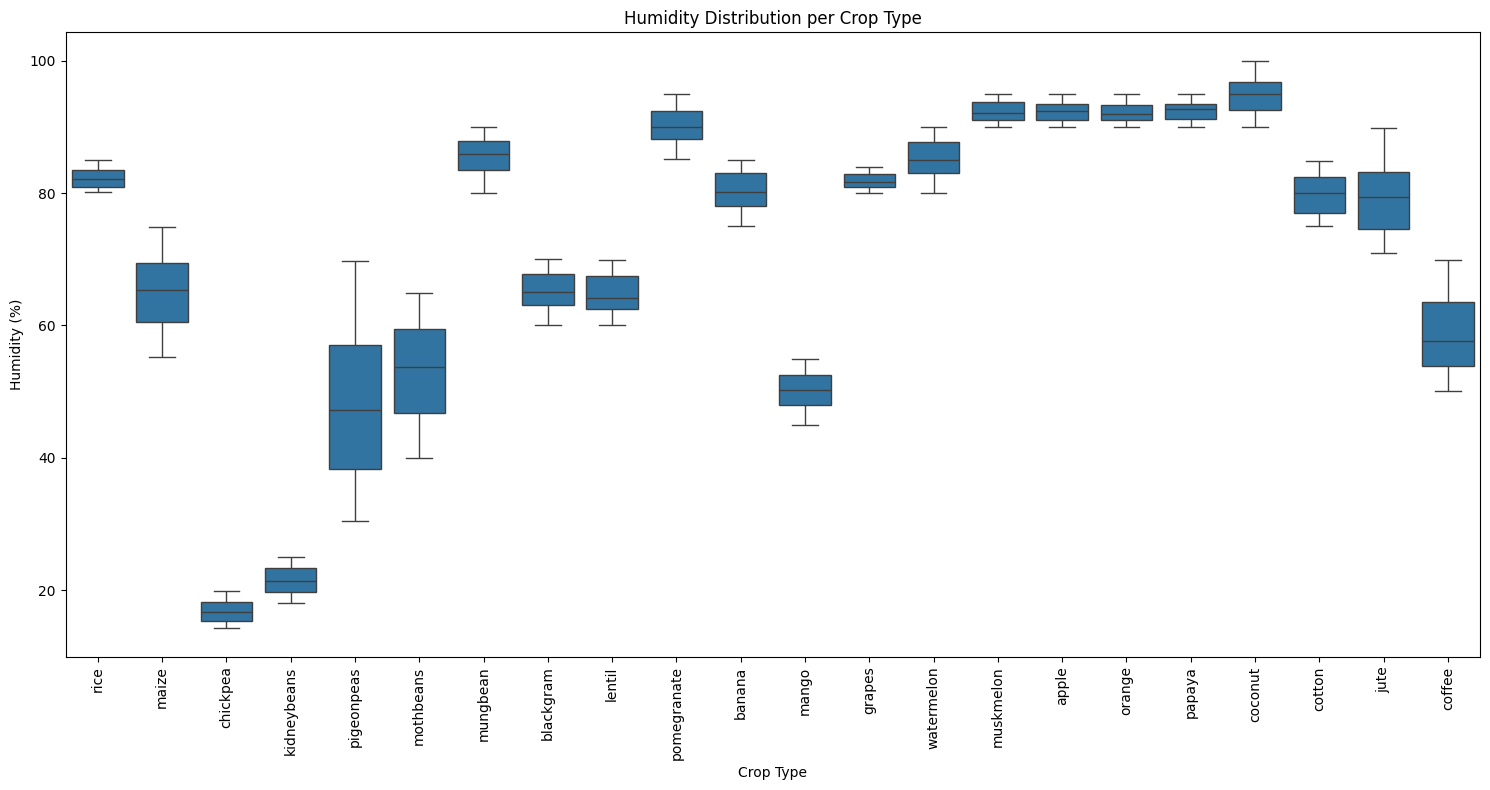

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='humidity', data=df_crop_recommendation)
plt.title('Humidity Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Humidity (%)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Relationship between pH and Crop Labels

Finally, let's examine the distribution of soil pH levels across various crop types. Soil pH is a critical factor influencing nutrient availability and crop growth, so understanding its variation for each crop will provide comprehensive insights.

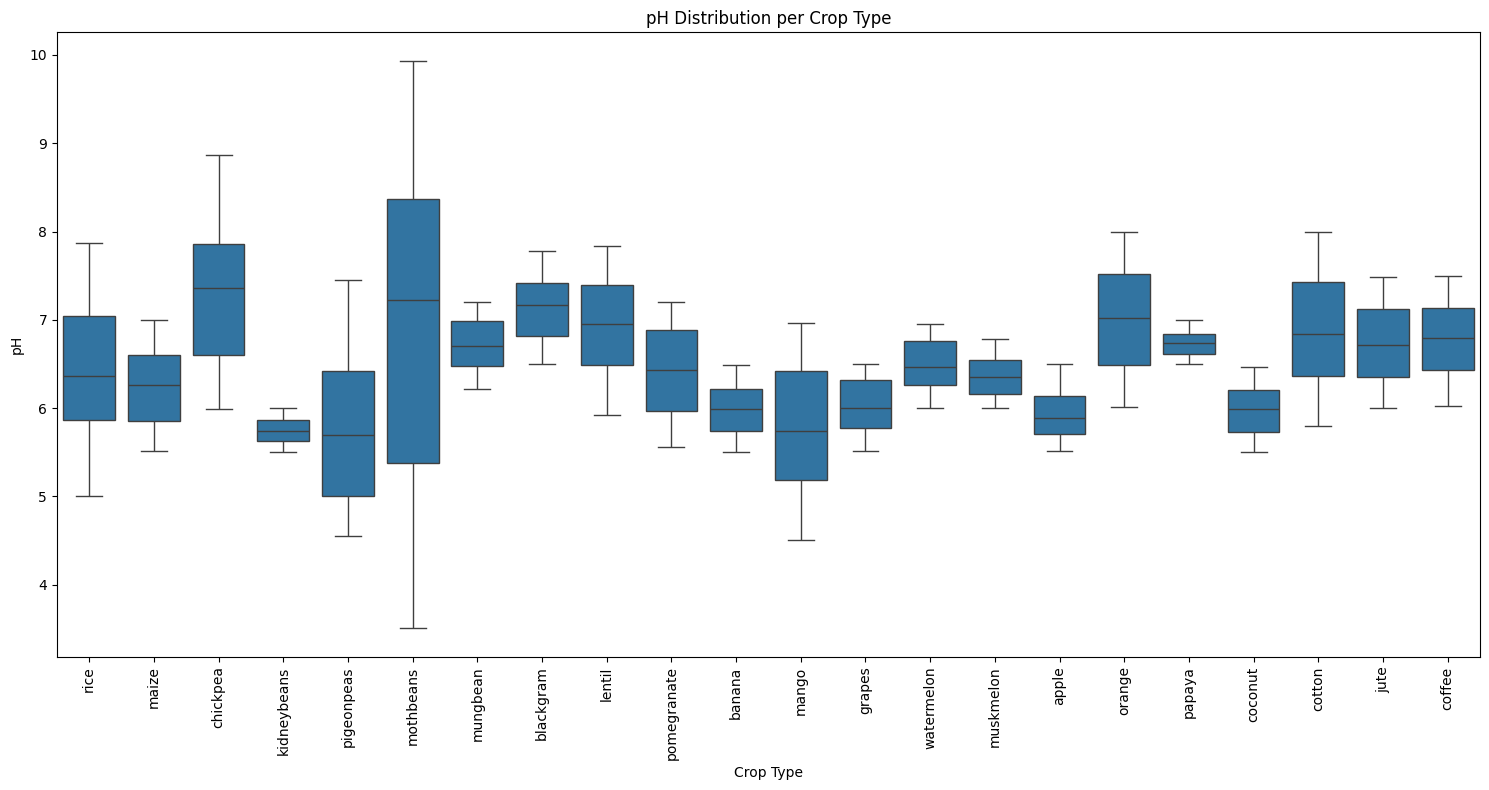

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='ph', data=df_crop_recommendation)
plt.title('pH Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('pH')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Relationship between Nitrogen (N) Levels and Crop Labels

To continue our analysis of nutrient factors, let's now visualize how Nitrogen (N) levels vary across different crop types. Nitrogen is a primary macronutrient essential for plant growth, and its optimal concentration differs significantly among crops.

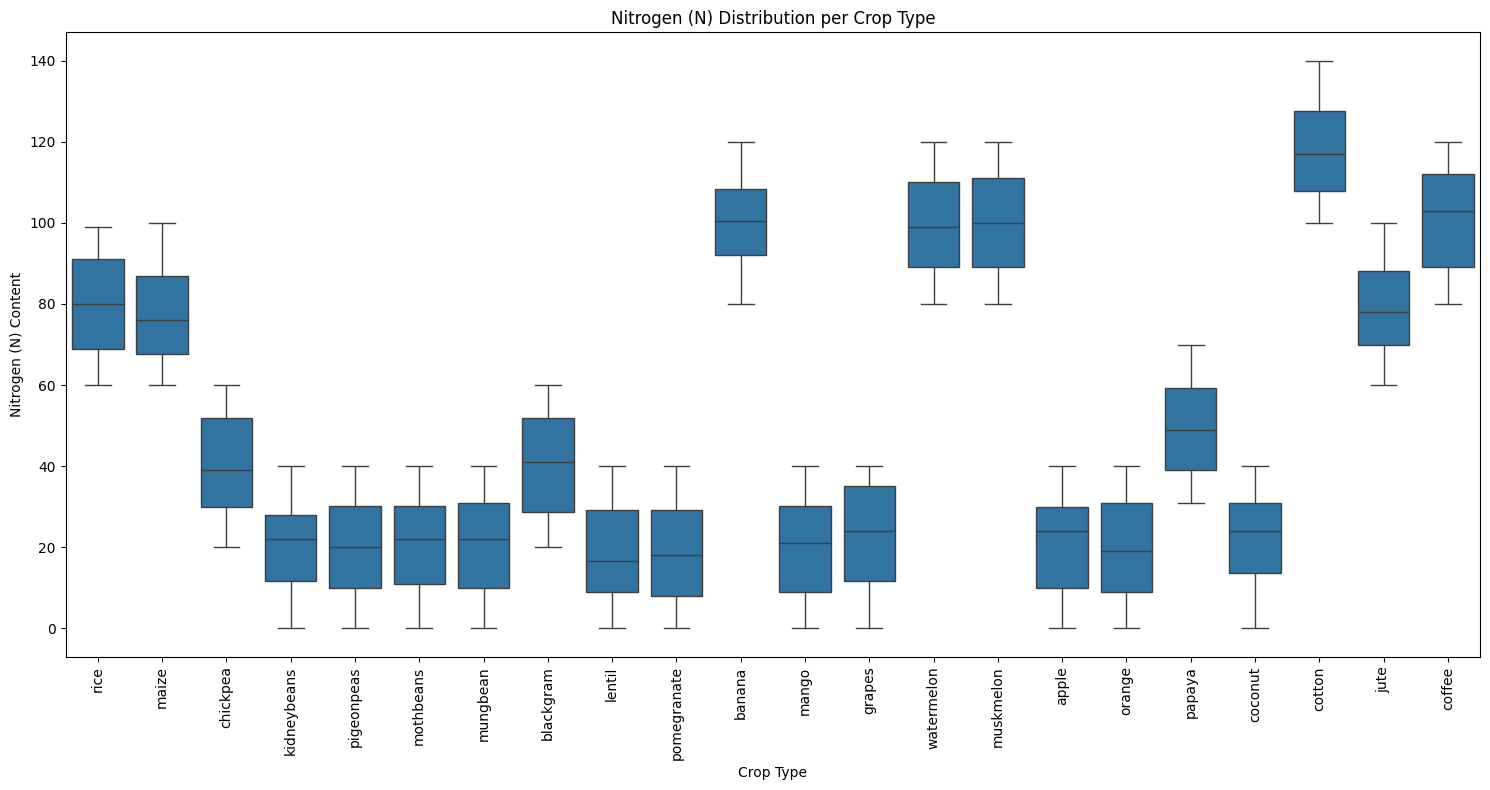

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='N', data=df_crop_recommendation)
plt.title('Nitrogen (N) Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Nitrogen (N) Content')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Relationship between Phosphorus (P) Levels and Crop Labels

Continuing our nutrient analysis, let's now examine how Phosphorus (P) levels vary across different crop types. Phosphorus is another critical macronutrient essential for plant energy transfer and growth, and understanding its optimal range for each crop is key for agricultural planning.

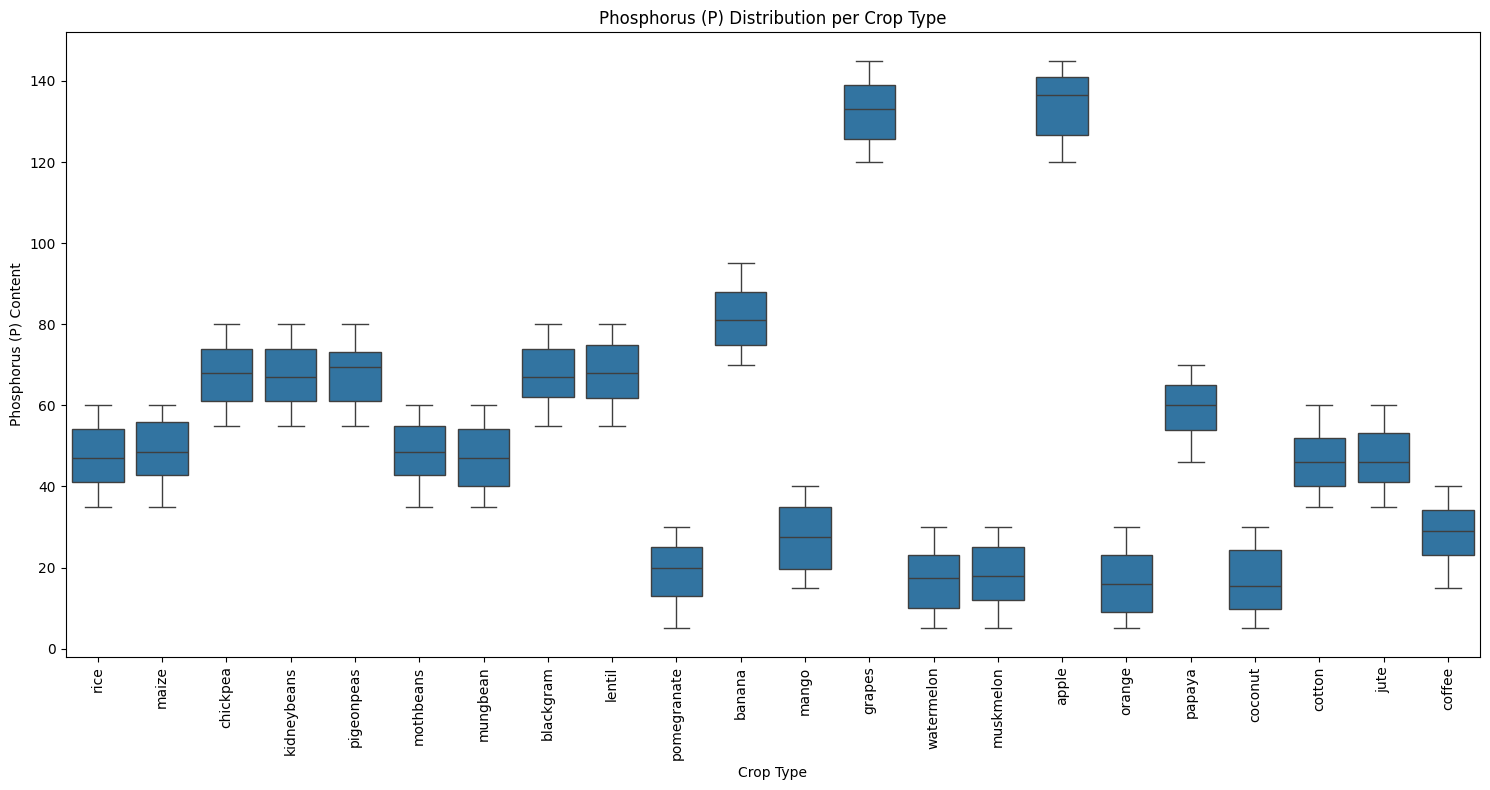

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='P', data=df_crop_recommendation)
plt.title('Phosphorus (P) Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Phosphorus (P) Content')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Crops with Highest Phosphorus (P) Requirements

In [21]:
average_p_by_crop = df_crop_recommendation.groupby('label')['P'].mean().sort_values(ascending=False)
print('Crops with the highest average Phosphorus (P) requirements:')
display(average_p_by_crop.head())

Crops with the highest average Phosphorus (P) requirements:


,P
label,
apple,134.22
grapes,132.53
banana,82.01
lentil,68.36
chickpea,67.79


### Relationship between Potassium (K) Levels and Crop Labels

To complete our analysis of the primary macronutrients, let's now examine how Potassium (K) levels vary across different crop types. Potassium plays a crucial role in plant water regulation, nutrient transport, and disease resistance, making its optimal concentration vital for healthy crop development.

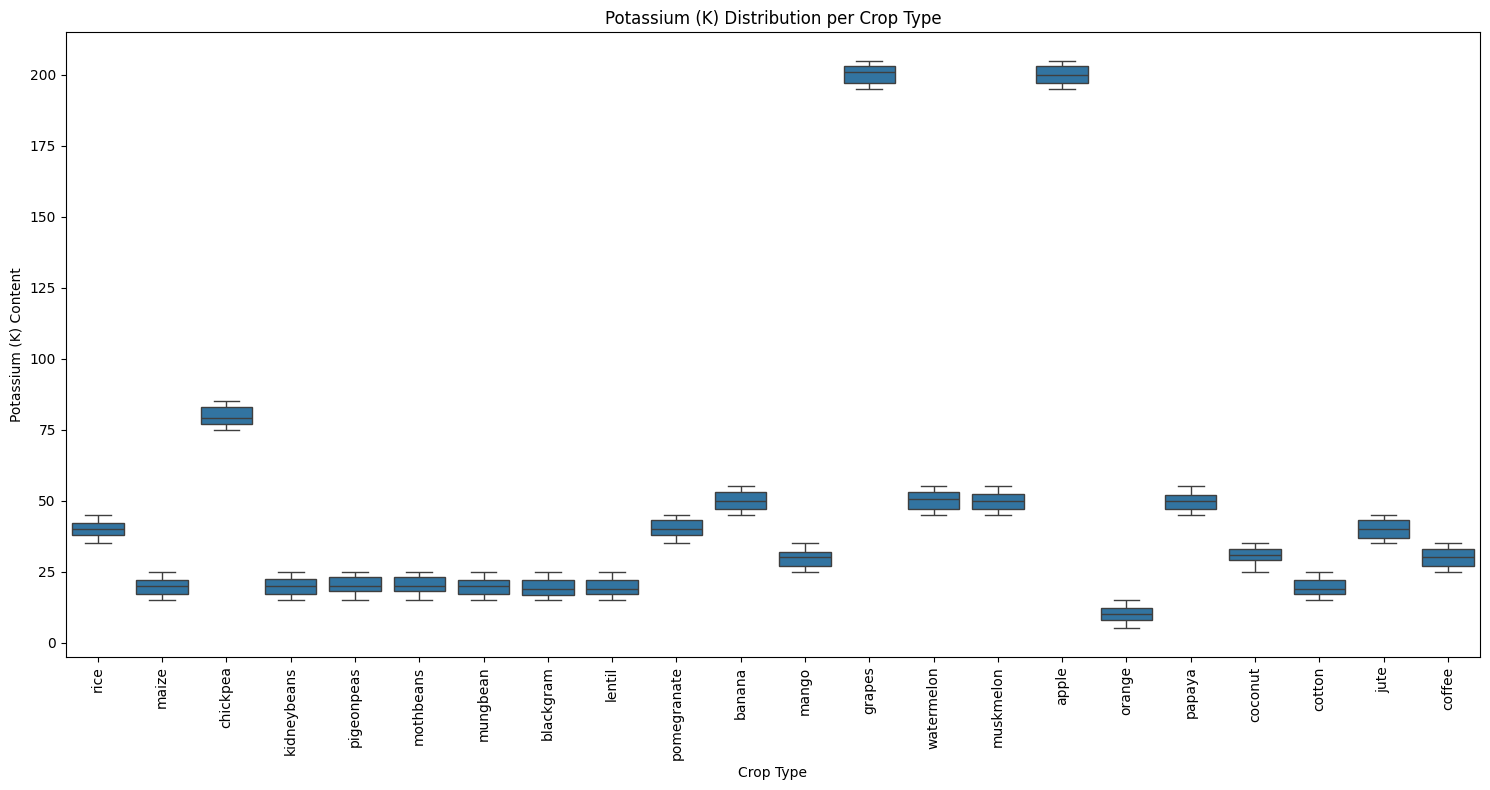

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='K', data=df_crop_recommendation)
plt.title('Potassium (K) Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Potassium (K) Content')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Crops with Highest Potassium (K) Requirements

In [22]:
average_k_by_crop = df_crop_recommendation.groupby('label')['K'].mean().sort_values(ascending=False)
print('Crops with the highest average Potassium (K) requirements:')
display(average_k_by_crop.head())

Crops with the highest average Potassium (K) requirements:


,K
label,
grapes,200.11
apple,199.89
chickpea,79.92
watermelon,50.22
muskmelon,50.08


### Cross-Dataset Correlation Analysis: Soil and Fertilizer Data

To understand the relationships between environmental factors, nutrient levels, and fertilizer recommendations across our datasets, we will perform a cross-dataset correlation analysis. This involves:
1.  **Aggregating data by crop type** from both `df_crop_recommendation` and `df_fertilizer`.
2.  **Merging** these aggregated datasets on crop type.
3.  **Calculating and visualizing the correlation matrix** of the combined features.

In [39]:
# Aggregate df_crop_recommendation by 'label' (crop type)
# Select relevant numerical columns and calculate their mean
df_crop_agg = df_crop_recommendation.groupby('label').agg({
    'N': 'mean',
    'P': 'mean',
    'K': 'mean',
    'temperature': 'mean',
    'humidity': 'mean',
    'ph': 'mean',
    'rainfall': 'mean'
}).reset_index()

# Rename columns to clearly distinguish them after merging
df_crop_agg.columns = ['crop_type', 'N_soil', 'P_soil', 'K_soil', 'temp_soil', 'humidity_soil', 'ph_soil', 'rainfall_soil']

display(df_crop_agg.head())

,crop_type,N_soil,P_soil,K_soil,temp_soil,humidity_soil,ph_soil,rainfall_soil
0,apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
1,banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
2,blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
3,chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
4,coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646


In [43]:
# Aggregate df_fertilizer by 'Crop Type'
# Select relevant numerical columns and calculate their mean
df_fertilizer_agg = df_fertilizer.groupby('Crop Type').agg({
    'Nitrogen': 'mean',
    'Phosphorous': 'mean',
    'Potassium': 'mean',
    'Temparature': 'mean',
    'Humidity ': 'mean' # Corrected column name to include the trailing space
}).reset_index()

# Rename columns to clearly distinguish them and match for merging
df_fertilizer_agg.columns = ['crop_type', 'N_fert', 'P_fert', 'K_fert', 'temp_fert', 'humidity_fert']

display(df_fertilizer_agg.head())

,crop_type,N_fert,P_fert,K_fert,temp_fert,humidity_fert
0,Barley,12.571429,26.000000,5.285714,30.142857,59.000000
1,Cotton,16.416667,23.833333,3.333333,30.416667,59.583333
2,Ground Nuts,23.285714,21.571429,2.000000,30.142857,59.142857
3,Maize,18.333333,18.666667,5.666667,29.000000,57.333333
4,Millets,23.181818,14.363636,0.000000,29.454545,57.272727


In [44]:
# Merge the two aggregated dataframes on 'crop_type'
# Use an inner merge to only include crop types present in both datasets
merged_df = pd.merge(df_crop_agg, df_fertilizer_agg, on='crop_type', how='inner')

print(f"Number of common crop types: {len(merged_df)}")
display(merged_df.head())

Number of common crop types: 0


,crop_type,N_soil,P_soil,K_soil,temp_soil,humidity_soil,ph_soil,rainfall_soil,N_fert,P_fert,K_fert,temp_fert,humidity_fert


/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


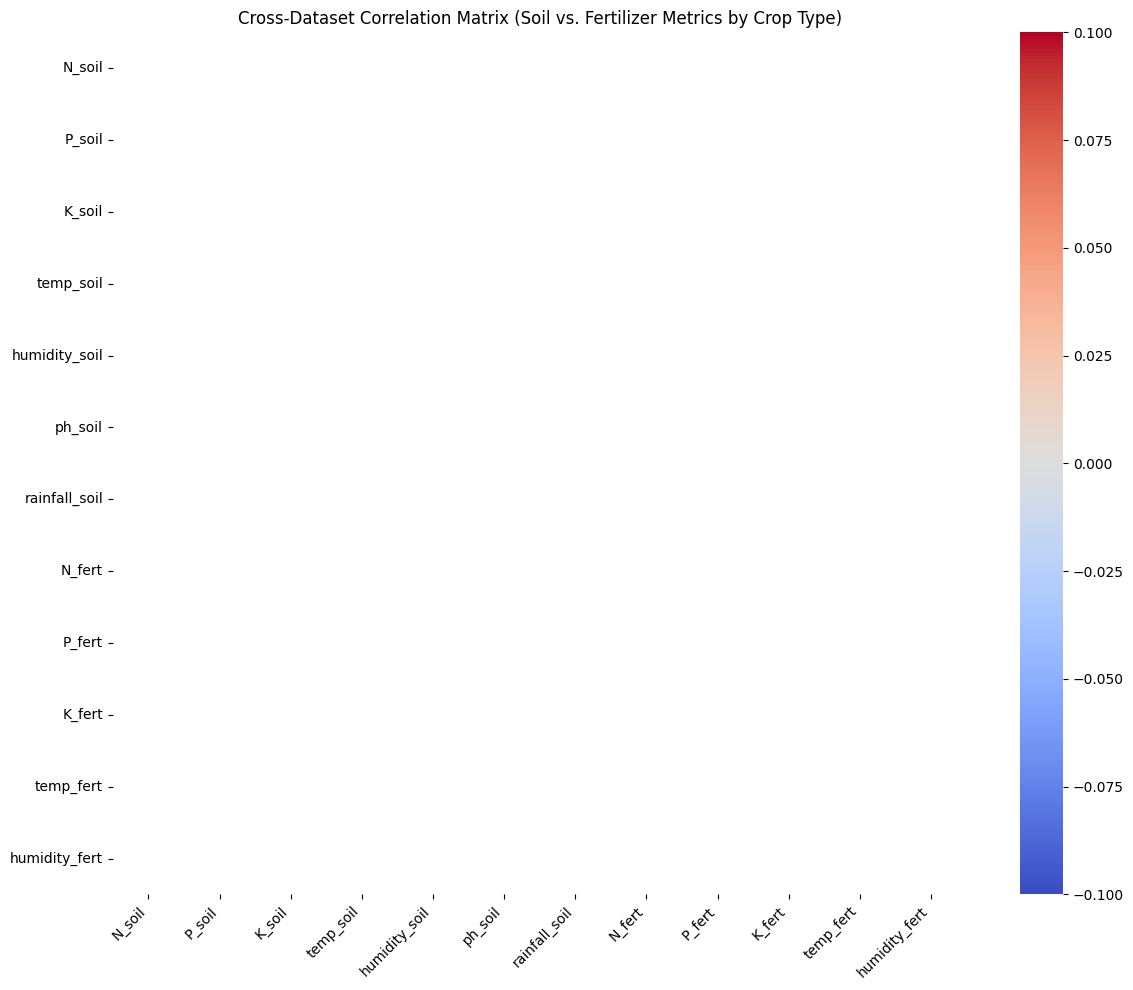

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix for the merged dataframe
cross_dataset_correlation = merged_df.drop('crop_type', axis=1).corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(cross_dataset_correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Cross-Dataset Correlation Matrix (Soil vs. Fertilizer Metrics by Crop Type)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Investigating Disjoint Crop Types

Since the merged dataframe is empty, let's examine the unique crop types in each of the aggregated dataframes (`df_crop_agg` and `df_fertilizer_agg`) to understand why there are no common entries.

In [48]:
print('Unique Crop Types in df_crop_agg:')
display(df_crop_agg['crop_type'].unique())

print('\nUnique Crop Types in df_fertilizer_agg:')
display(df_fertilizer_agg['crop_type'].unique())

Unique Crop Types in df_crop_agg:


array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)


Unique Crop Types in df_fertilizer_agg:


array(['Barley', 'Cotton', 'Ground Nuts', 'Maize', 'Millets', 'Oil seeds',
       'Paddy', 'Pulses', 'Sugarcane', 'Tobacco', 'Wheat'], dtype=object)

As observed, the crop names between the two datasets are largely different. Even after accounting for potential case differences, there appear to be very few or no direct matches (e.g., 'rice' vs. 'Paddy', 'maize' vs. 'Maize'). This explains why the `pd.merge` operation resulted in an empty DataFrame.

To proceed with a meaningful cross-dataset correlation, we would either need:
1.  **A mapping:** A dictionary or rule to map crop names from one dataset to another if they refer to the same crop but are named differently.
2.  **More overlapping data:** Datasets that inherently share more common crop types.

Given the current data, a direct correlation across all original features for common crop types is not feasible as no such common types exist. We could potentially perform an analysis of feature correlations within each dataset separately, or consider a different approach if there's an implicit relationship between the crops that isn't directly reflected in their names.

### Investigating Disjoint Crop Types

Since the merged dataframe is empty, let's examine the unique crop types in each of the aggregated dataframes (`df_crop_agg` and `df_fertilizer_agg`) to understand why there are no common entries.

In [47]:
print('Unique Crop Types in df_crop_agg:')
display(df_crop_agg['crop_type'].unique())

print('\nUnique Crop Types in df_fertilizer_agg:')
display(df_fertilizer_agg['crop_type'].unique())

Unique Crop Types in df_crop_agg:


array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)


Unique Crop Types in df_fertilizer_agg:


array(['Barley', 'Cotton', 'Ground Nuts', 'Maize', 'Millets', 'Oil seeds',
       'Paddy', 'Pulses', 'Sugarcane', 'Tobacco', 'Wheat'], dtype=object)

As observed, the crop names between the two datasets are largely different. Even after accounting for potential case differences, there appear to be very few or no direct matches (e.g., 'rice' vs. 'Paddy', 'maize' vs. 'Maize'). This explains why the `pd.merge` operation resulted in an empty DataFrame.

To proceed with a meaningful cross-dataset correlation, we would either need:
1.  **A mapping:** A dictionary or rule to map crop names from one dataset to another if they refer to the same crop but are named differently.
2.  **More overlapping data:** Datasets that inherently share more common crop types.

Given the current data, a direct correlation across all original features for common crop types is not feasible as no such common types exist. We could potentially perform an analysis of feature correlations within each dataset separately, or consider a different approach if there's an implicit relationship between the crops that isn't directly reflected in their names.

### Investigating Disjoint Crop Types

Since the merged dataframe is empty, let's examine the unique crop types in each of the aggregated dataframes (`df_crop_agg` and `df_fertilizer_agg`) to understand why there are no common entries.

In [46]:
print('Unique Crop Types in df_crop_agg:')
display(df_crop_agg['crop_type'].unique())

print('\nUnique Crop Types in df_fertilizer_agg:')
display(df_fertilizer_agg['crop_type'].unique())

Unique Crop Types in df_crop_agg:


array(['apple', 'banana', 'blackgram', 'chickpea', 'coconut', 'coffee',
       'cotton', 'grapes', 'jute', 'kidneybeans', 'lentil', 'maize',
       'mango', 'mothbeans', 'mungbean', 'muskmelon', 'orange', 'papaya',
       'pigeonpeas', 'pomegranate', 'rice', 'watermelon'], dtype=object)


Unique Crop Types in df_fertilizer_agg:


array(['Barley', 'Cotton', 'Ground Nuts', 'Maize', 'Millets', 'Oil seeds',
       'Paddy', 'Pulses', 'Sugarcane', 'Tobacco', 'Wheat'], dtype=object)

As observed, the crop names between the two datasets are largely different. Even after accounting for potential case differences, there appear to be very few or no direct matches (e.g., 'rice' vs. 'Paddy', 'maize' vs. 'Maize'). This explains why the `pd.merge` operation resulted in an empty DataFrame.

To proceed with a meaningful cross-dataset correlation, we would either need:
1.  **A mapping:** A dictionary or rule to map crop names from one dataset to another if they refer to the same crop but are named differently.
2.  **More overlapping data:** Datasets that inherently share more common crop types.

Given the current data, a direct correlation across all original features for common crop types is not feasible as no such common types exist. We could potentially perform an analysis of feature correlations within each dataset separately, or consider a different approach if there's an implicit relationship between the crops that isn't directly reflected in their names.

### Relationship between Nitrogen (N) Levels and Crop Labels

To continue our analysis of nutrient factors, let's now visualize how Nitrogen (N) levels vary across different crop types. Nitrogen is a primary macronutrient essential for plant growth, and its optimal concentration differs significantly among crops.

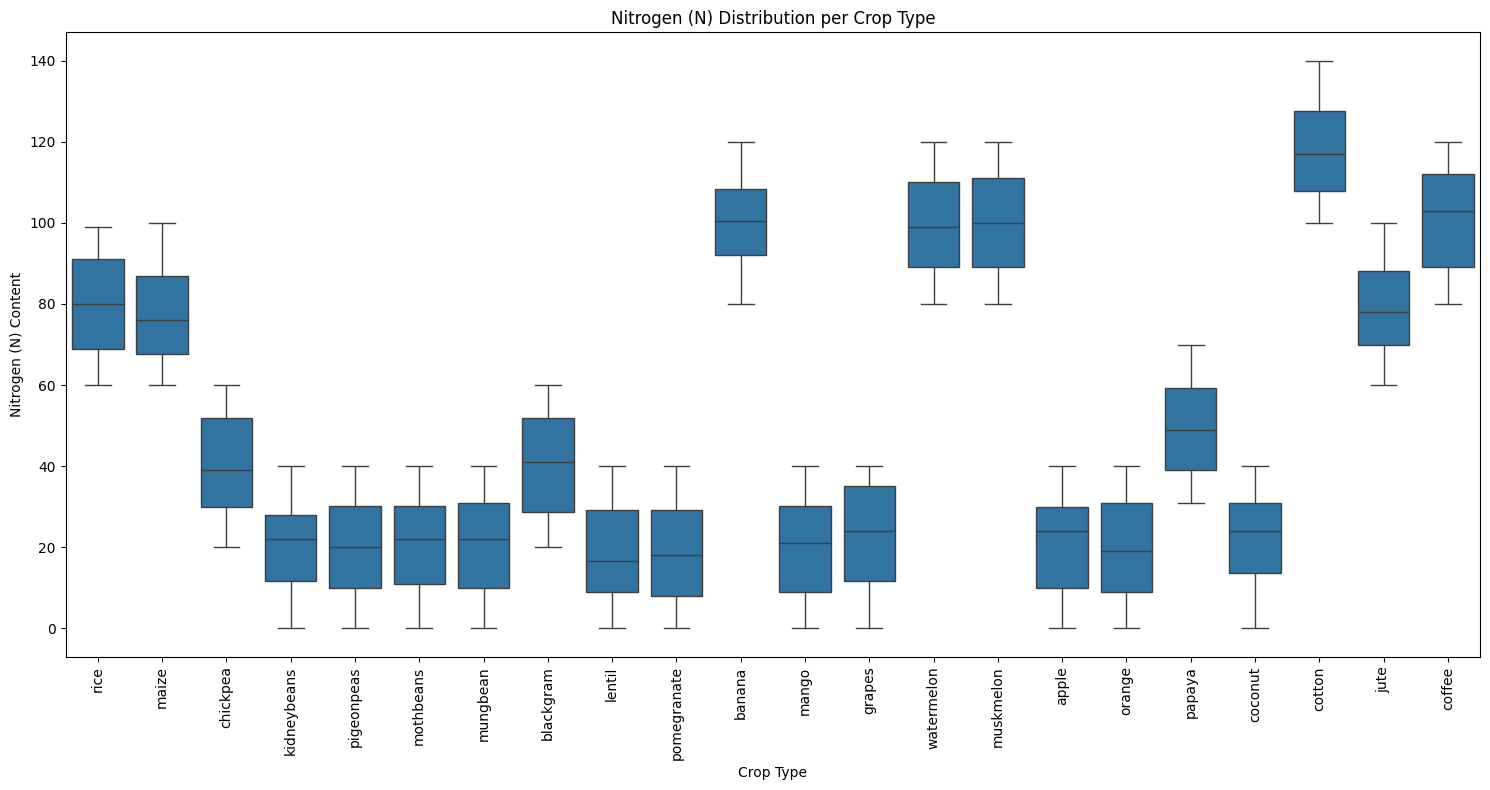

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='N', data=df_crop_recommendation)
plt.title('Nitrogen (N) Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Nitrogen (N) Content')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Relationship between Phosphorus (P) Levels and Crop Labels

Continuing our nutrient analysis, let's now examine how Phosphorus (P) levels vary across different crop types. Phosphorus is another critical macronutrient essential for plant energy transfer and growth, and understanding its optimal range for each crop is key for agricultural planning.

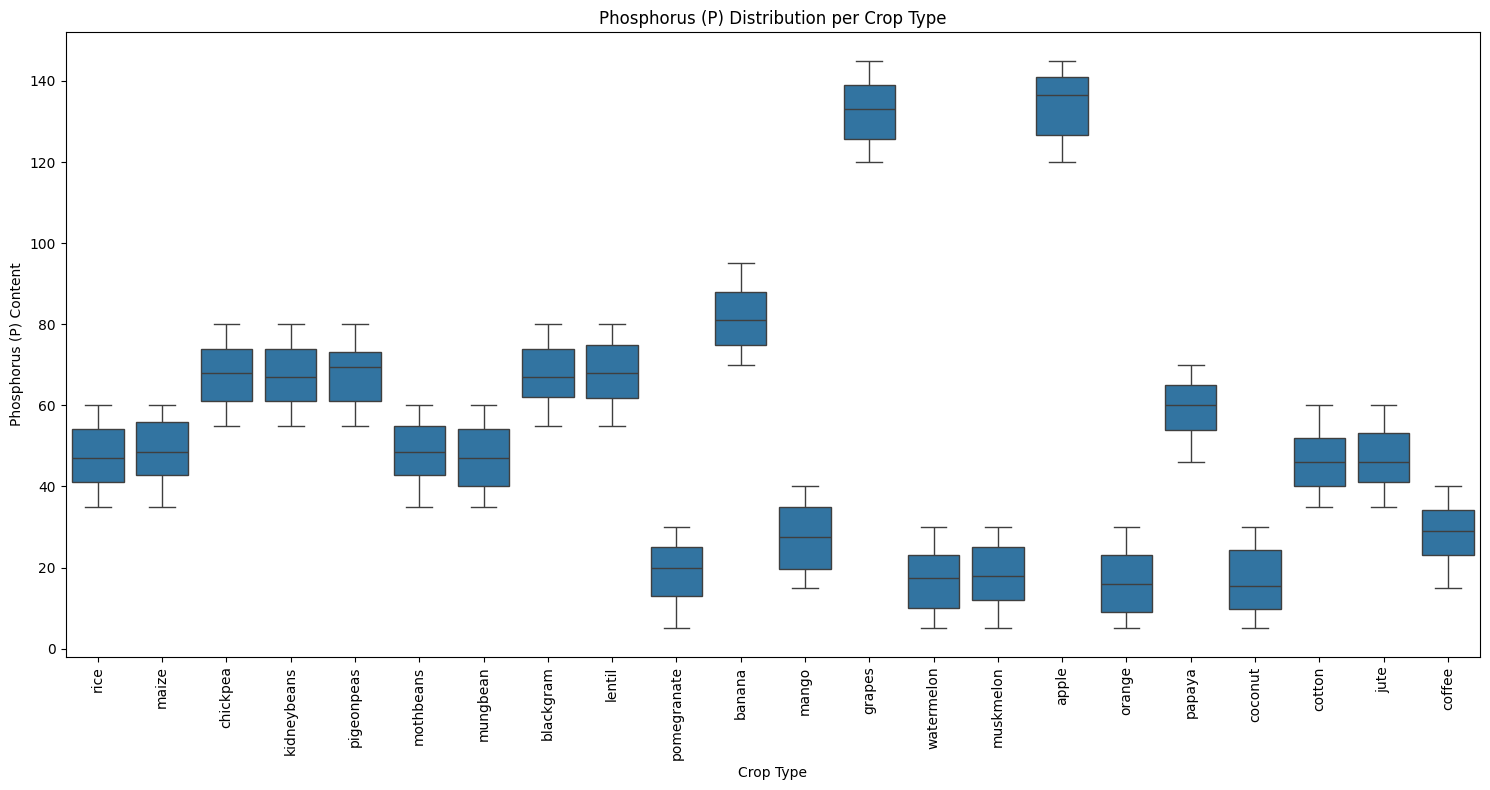

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='P', data=df_crop_recommendation)
plt.title('Phosphorus (P) Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Phosphorus (P) Content')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Relationship between Potassium (K) Levels and Crop Labels

To complete our analysis of the primary macronutrients, let's now examine how Potassium (K) levels vary across different crop types. Potassium plays a crucial role in plant water regulation, nutrient transport, and disease resistance, making its optimal concentration vital for healthy crop development.

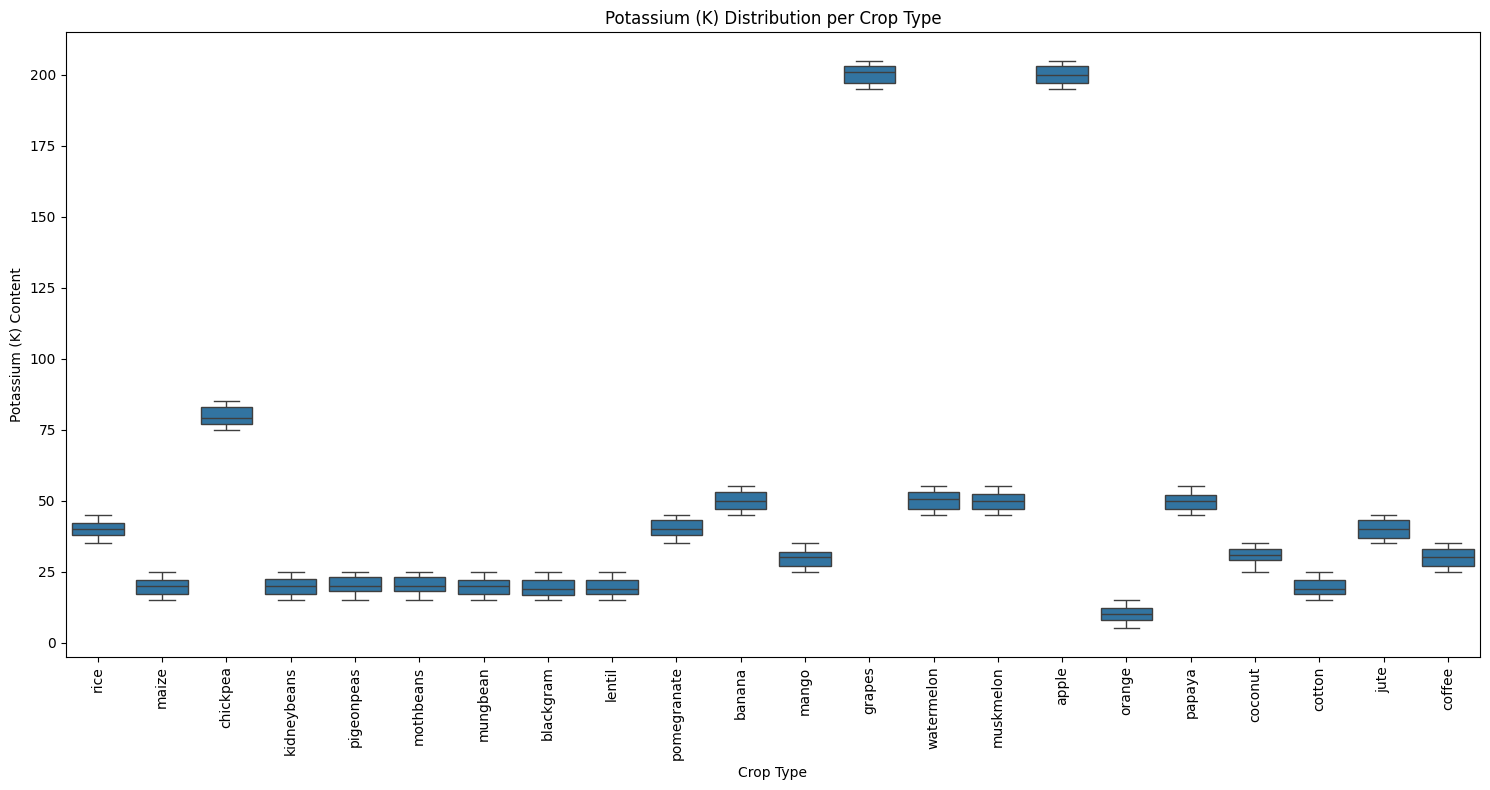

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='K', data=df_crop_recommendation)
plt.title('Potassium (K) Distribution per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Potassium (K) Content')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Average Rainfall by Crop Type

Let's visualize the average rainfall required by each crop type using a bar plot. This will highlight the varying water needs across different crops.

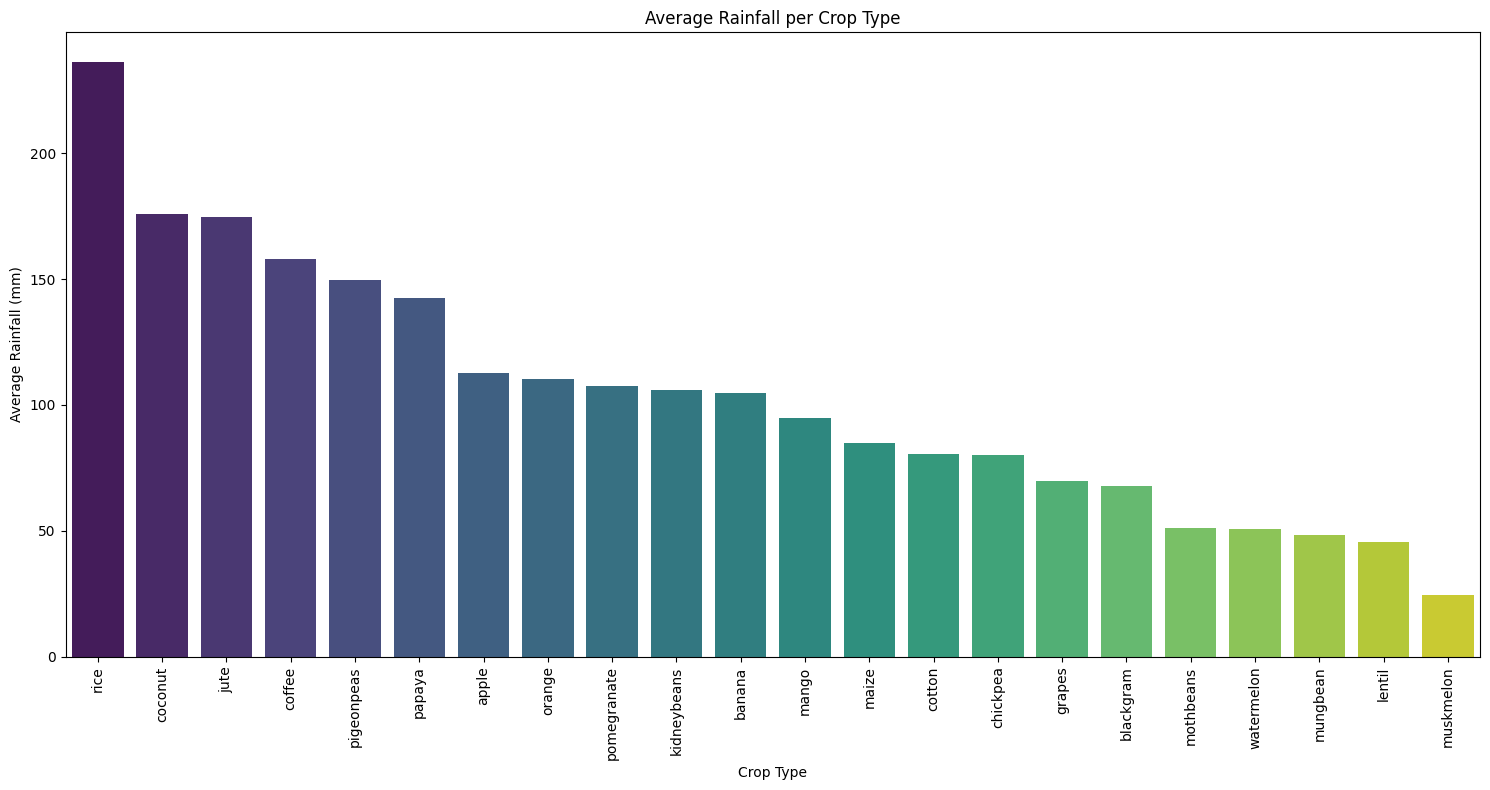

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average rainfall for each crop type
average_rainfall_by_crop = df_crop_recommendation.groupby('label')['rainfall'].mean().sort_values(ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x=average_rainfall_by_crop.index, y=average_rainfall_by_crop.values, hue=average_rainfall_by_crop.index, palette='viridis', legend=False)
plt.title('Average Rainfall per Crop Type')
plt.xlabel('Crop Type')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

The heatmap visualizes the correlation between features derived from the `Crop_recommendation.csv` (soil conditions) and `Fertilizer Prediction.csv` (fertilizer recommendations), aggregated by common crop types. Positive values indicate a positive correlation (as one increases, the other tends to increase), while negative values indicate a negative correlation (as one increases, the other tends to decrease). Values close to 1 or -1 indicate strong correlations.

Key areas to observe include:
-   **N_soil vs. N_fert, P_soil vs. P_fert, K_soil vs. K_fert**: This shows if crops requiring high levels of a nutrient in soil (from `df_crop_recommendation`) are also recommended high levels of that nutrient in fertilizer (from `df_fertilizer`).
-   **Environmental factors correlation**: How `temp_soil` and `humidity_soil` correlate with `temp_fert` and `humidity_fert`.

This analysis helps in understanding if the fertilizer recommendations in `df_fertilizer` align with the optimal soil conditions and nutrient requirements suggested by `df_crop_recommendation` for overlapping crop types.

### Feature Correlation Matrix

To further understand the relationships between the various environmental and nutrient factors, let's calculate and visualize their correlation matrix. A correlation matrix shows the correlation coefficients between different variables, indicating the strength and direction of their linear relationships.

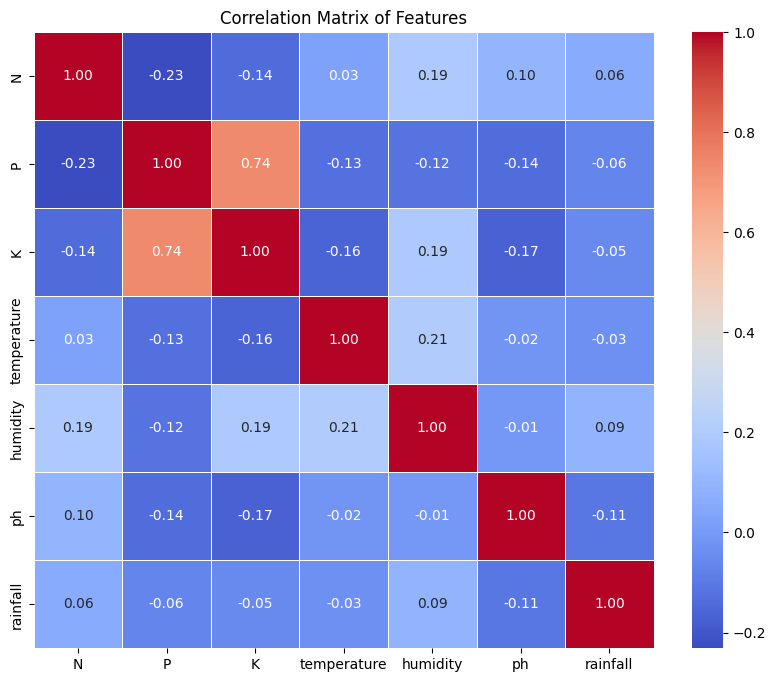

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix for the features (X)
correlation_matrix = X.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Features')
plt.show()

### Scatter Plot of Potassium (K) versus Phosphorus (P)

Let's visualize the relationship between Potassium (K) and Phosphorus (P) using a scatter plot to see if there's any direct correlation or pattern between these two nutrients in the `df_crop_recommendation` dataset.

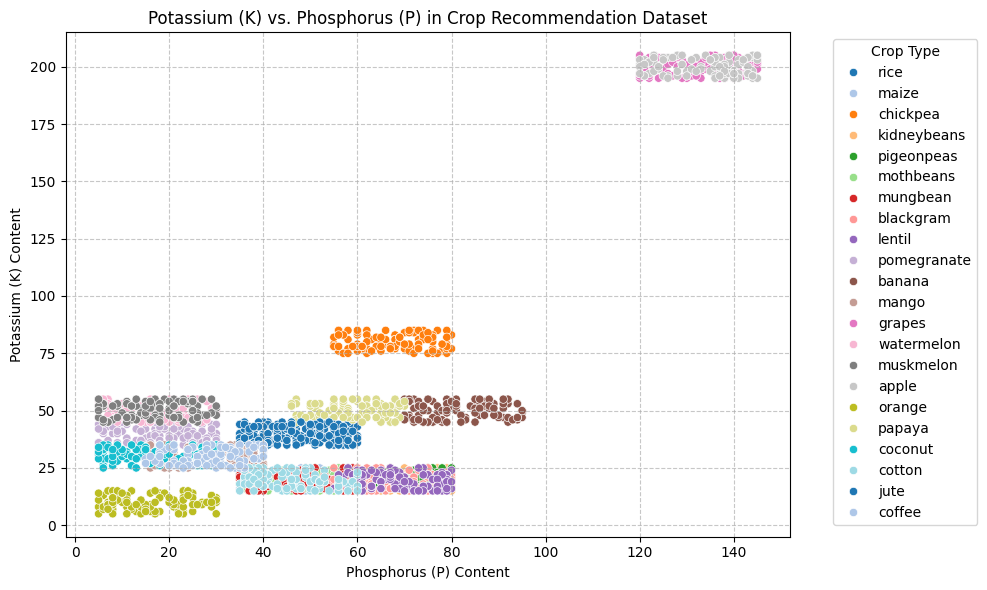

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='P', y='K', data=df_crop_recommendation, hue='label', palette='tab20')
plt.title('Potassium (K) vs. Phosphorus (P) in Crop Recommendation Dataset')
plt.xlabel('Phosphorus (P) Content')
plt.ylabel('Potassium (K) Content')
plt.legend(title='Crop Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()